# Przygotowanie danych dla zbioru Mushroom

### Preprocessing danych i analiza wstepna:
1. [Import bibliotek](#0)
2. [Wczytanie danych](#1)
3. [Podstawowe informacje o zbiorze](#2)
4. [Analiza zbalansowania klas](#3)
5. [Podzial danych](#4)
6. [Analiza brakujacych wartosci](#5)
7. [Preprocessing danych](#6)
8. [Wizualizacja wybranych cech](#7)
9. [Korelacja cech modelu](#8)
10. [Podglad wynikow wszystkich modeli](#9)


### <a name='0'></a> Import bibliotek

W pierwszym kroku importujemy biblioteki potrzebne do:
- pracy z danymi tabelarycznymi,
- przygotowania danych do modelu,
- trenowania klasyfikatorow,
- oceny skutecznosci modeli.

Wspolna logika zostala wyniesiona do pliku `mushroom_analysis.py`,
aby wszystkie notebooki korzystaly z tej samej procedury preprocessingu.


In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from mushroom_analysis import (
    TARGET_COLUMN,
    BernoulliNB,
    DecisionTreeClassifier,
    KNeighborsClassifier,
    LogisticRegression,
    RANDOM_STATE,
    RandomForestClassifier,
    class_balance_table,
    evaluate_models,
    load_data,
    load_dataset,
    missing_values_table,
    oversample_minority_class,
    plot_class_distribution,
    plot_confusion_matrix_for_model,
    plot_feature_histograms,
    plot_top_feature_correlations,
    preprocess_after_split,
    split_dataset,
)


### <a name='1'></a> Wczytanie danych

Zbior `agaricus-lepiota.data` zawiera informacje o cechach grzybow
oraz zmiennej docelowej `class`, ktora informuje, czy dany grzyb
jest jadalny (`e`) czy trujacy (`p`).


In [16]:
df = load_data()
df.head()


,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### <a name='2'></a> Podstawowe informacje o zbiorze

Na tym etapie sprawdzamy rozmiar zbioru. Pozwala to potwierdzic,
ile obserwacji i ile cech bedzie bralo udzial w analizie.


In [17]:
df.shape


(8124, 23)

### <a name='3'></a> Analiza zbalansowania klas

Przed budowa modelu nalezy sprawdzic, czy klasy w zbiorze sa rownomiernie
reprezentowane. Silna nierownowaga moglaby prowadzic do zawyzonych metryk
i wymagalaby dodatkowych technik balansowania.


In [18]:
class_balance_table(df[TARGET_COLUMN])


,class_code,class_name,count,percentage
0,e,edible,4208,51.8
1,p,poisonous,3916,48.2


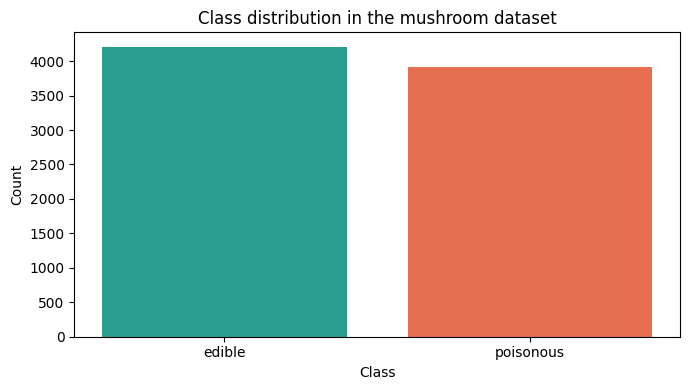

In [19]:
plot_class_distribution(df[TARGET_COLUMN])


In [20]:
balance_df = class_balance_table(df[TARGET_COLUMN])
edible_row = balance_df[balance_df["class_code"] == "e"].iloc[0]
poisonous_row = balance_df[balance_df["class_code"] == "p"].iloc[0]

print(
    f"Wnioski: w zbiorze znajduje sie {int(edible_row['count'])} grzybow jadalnych "
    f"({edible_row['percentage']:.1f}%) oraz {int(poisonous_row['count'])} grzybow trujacych "
    f"({poisonous_row['percentage']:.1f}%). Oznacza to, ze klasy sa prawie zbalansowane."
)


Wnioski: w zbiorze znajduje sie 4208 grzybow jadalnych (51.8%) oraz 3916 grzybow trujacych (48.2%). Oznacza to, ze klasy sa prawie zbalansowane.


### <a name='4'></a> Podzial danych na zbiory treningowy, walidacyjny i testowy

Zgodnie z zalozeniami projektowymi dzielimy dane w proporcji `70/15/15`.
Podzial wykonywany jest przed imputacja brakow, aby uniknac przecieku danych.


In [21]:
train_df, validation_df, test_df = split_dataset(df)

pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df)},
        {"split": "validation", "rows": len(validation_df)},
        {"split": "test", "rows": len(test_df)},
    ]
)


,split,rows
0,train,5686
1,validation,1219
2,test,1219


### <a name='5'></a> Analiza brakujacych wartosci

W zbiorze mushroom brakujace wartosci sa szczegolnie istotne,
poniewaz niektore cechy kategorii zawieraja symbole `?`.
Po podziale danych sprawdzamy, gdzie wystepuja braki i w jakiej skali.


In [22]:
missing_values_table(
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
)


,split,column,missing_count
0,train,stalk_root,1740
1,validation,stalk_root,363
2,test,stalk_root,377


In [23]:
missing_df = missing_values_table(
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
)

total_missing = int(missing_df["missing_count"].sum())
train_missing = int(missing_df.loc[missing_df["split"] == "train", "missing_count"].sum())
validation_missing = int(missing_df.loc[missing_df["split"] == "validation", "missing_count"].sum())
test_missing = int(missing_df.loc[missing_df["split"] == "test", "missing_count"].sum())

print(
    f"Wnioski: wykryto lacznie {total_missing} brakujacych wartosci, "
    f"w tym {train_missing} w zbiorze treningowym, {validation_missing} w walidacyjnym "
    f"oraz {test_missing} w testowym. Braki wystepuja w kolumnie 'stalk_root', "
    f"dlatego imputacja po podziale danych jest konieczna."
)


Wnioski: wykryto lacznie 2480 brakujacych wartosci, w tym 1740 w zbiorze treningowym, 363 w walidacyjnym oraz 377 w testowym. Braki wystepuja w kolumnie 'stalk_root', dlatego imputacja po podziale danych jest konieczna.


### <a name='6'></a> Preprocessing danych

W tej sekcji wykonujemy:
- imputacje najczesciej wystepujacej kategorii,
- kodowanie zmiennej docelowej do postaci numerycznej,
- kodowanie cech kategorycznych z wykorzystaniem One-Hot Encoding.

Taki sposob przygotowania danych jest odpowiedni dla analizowanych modeli.


In [24]:
preprocessed = preprocess_after_split(train_df, validation_df, test_df)

print("X_train_encoded:", preprocessed["X_train_encoded"].shape)
print("X_validation_encoded:", preprocessed["X_validation_encoded"].shape)
print("X_test_encoded:", preprocessed["X_test_encoded"].shape)


X_train_encoded: (5686, 116)
X_validation_encoded: (1219, 116)
X_test_encoded: (1219, 116)


### <a name='7'></a> Wizualizacja wybranych cech

Histogramy pomagaja zrozumiec rozklad kategorii dla cech,
ktore moga miec duze znaczenie przy rozroznianiu grzybow jadalnych
i trujacych.

W przypadku datasetu mushroom surowe kody literowe zostaly
automatycznie zamienione na pelne, czytelne nazwy kategorii,
aby prezentacja wynikow byla bardziej zrozumiala.


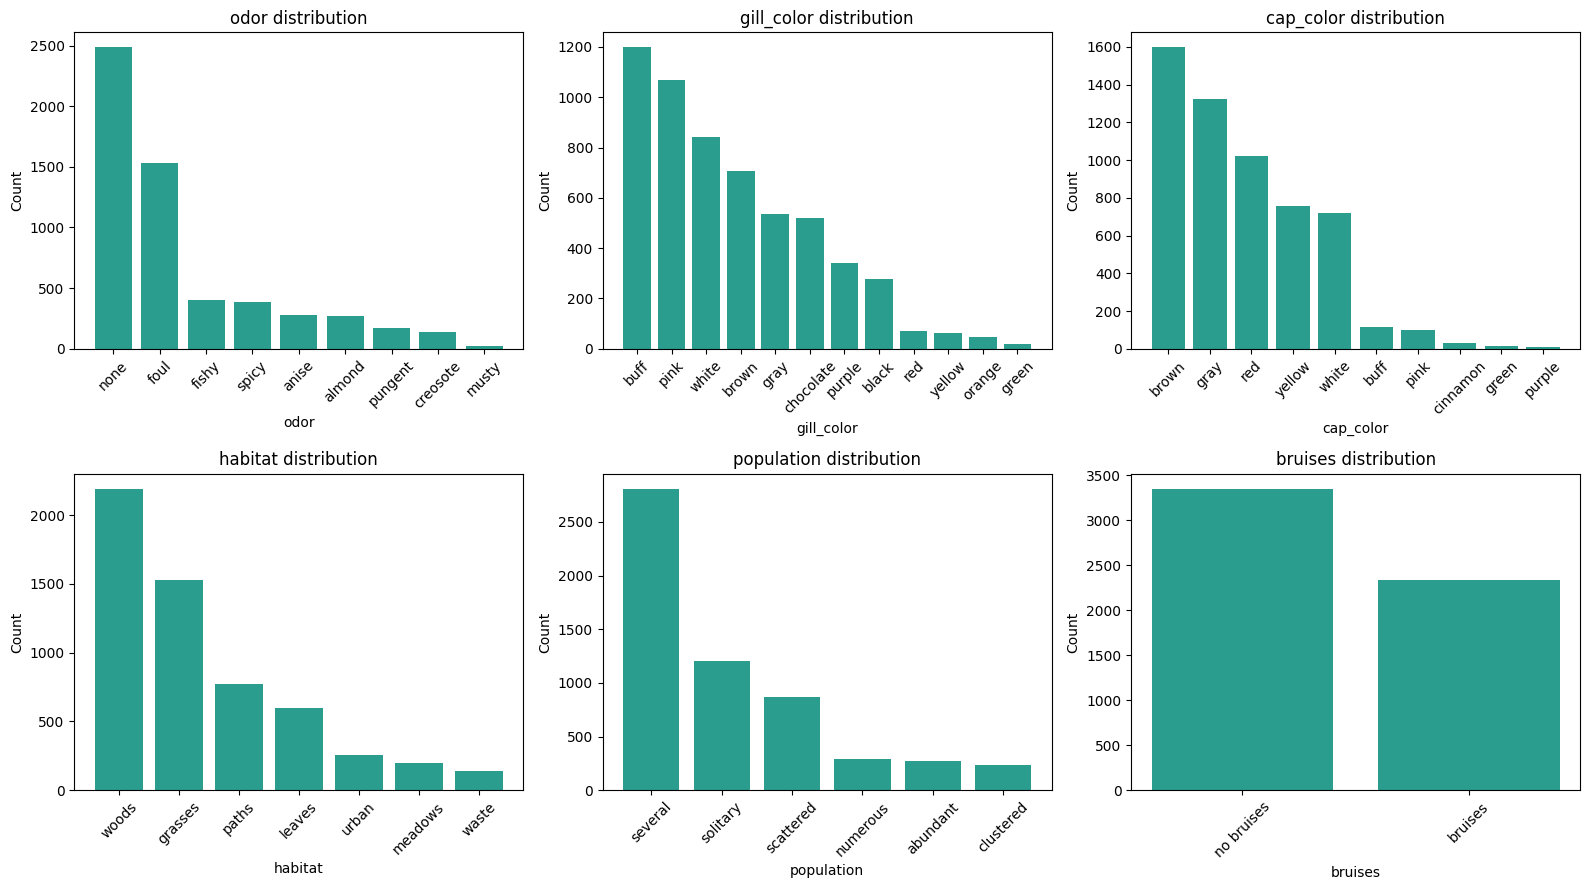

In [25]:
plot_feature_histograms(train_df)


### <a name='8'></a> Korelacja cech modelu

Po zakodowaniu cech mozemy sprawdzic, ktore z nich wykazuja
najsilniejszy zwiazek ze zmienna docelowa. Pozwala to lepiej
uzasadnic, dlaczego model osiagnie okreslone wyniki.


c:\Users\imper\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\imper\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


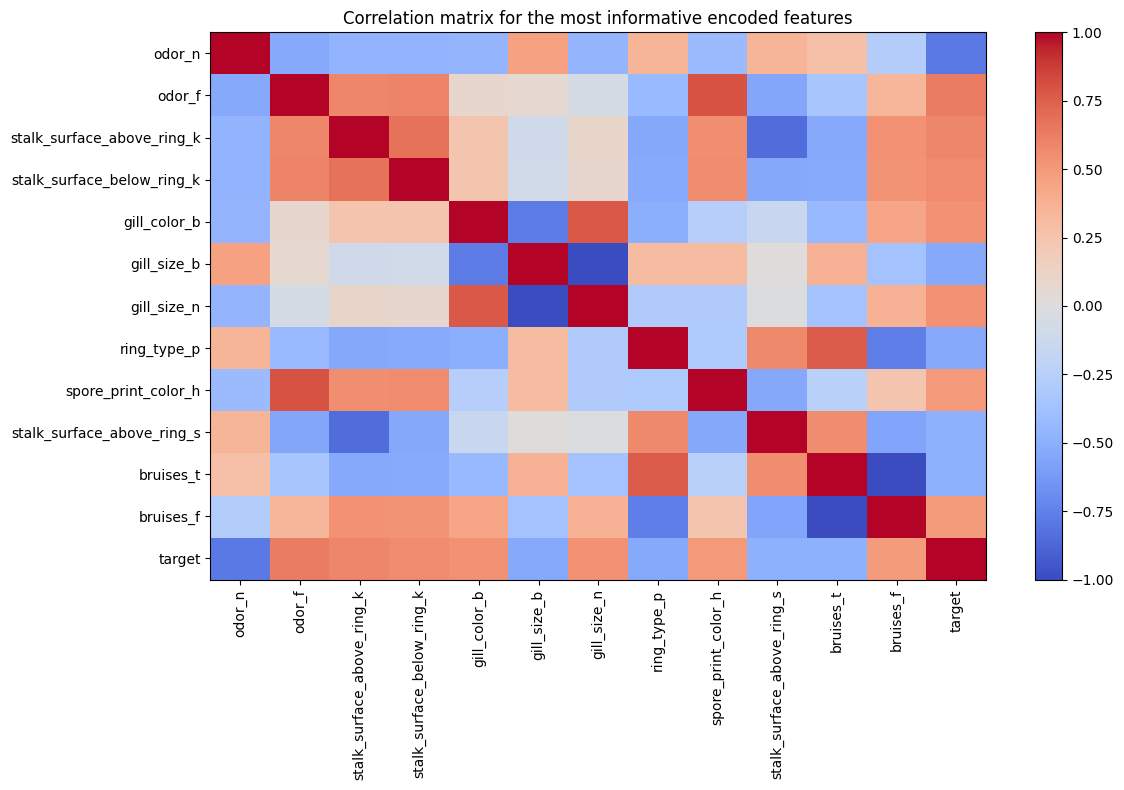

,encoded_feature,absolute_target_correlation,feature_description
0,odor_n,0.787583,odor = none
1,odor_f,0.628640,odor = foul
2,stalk_surface_above_ring_k,0.587159,stalk_surface_above_ring = silky
3,stalk_surface_below_ring_k,0.569723,stalk_surface_below_ring = silky
4,gill_color_b,0.535538,gill_color = buff
5,gill_size_b,0.533433,gill_size = broad
6,gill_size_n,0.533433,gill_size = narrow
7,ring_type_p,0.531636,ring_type = pendant
8,spore_print_color_h,0.494189,spore_print_color = chocolate
9,stalk_surface_above_ring_s,0.491034,stalk_surface_above_ring = smooth


In [26]:
top_correlations = plot_top_feature_correlations(
    preprocessed["X_train_encoded"],
    preprocessed["y_train"],
    top_n=12,
    feature_columns=preprocessed["feature_columns"],
)
top_correlations


In [27]:
strongest = top_correlations.iloc[0]
print(
    f"Wnioski: najsilniej z targetem powiazana jest cecha "
    f"'{strongest['encoded_feature']}' o bezwzglednej korelacji "
    f"{strongest['absolute_target_correlation']:.4f}. Potwierdza to, ze czesc cech "
    f"bardzo dobrze rozroznia klasy jadalne i trujace."
)


Wnioski: najsilniej z targetem powiazana jest cecha 'odor_n' o bezwzglednej korelacji 0.7876. Potwierdza to, ze czesc cech bardzo dobrze rozroznia klasy jadalne i trujace.


### <a name='9'></a> Podglad wynikow wszystkich modeli

Zanim przejdziemy do osobnych notebookow modelowych,
warto zobaczyc zbiorcze porownanie wszystkich pieciu algorytmow.


In [28]:
results_df = evaluate_models(preprocessed).drop(columns="fitted_model")
results_df


,model,balancing_strategy,validation_accuracy,validation_precision,validation_recall,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,Decision Tree,class_weight,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,class_weight,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Logistic Regression,class_weight,0.9992,1.0000,0.9983,0.9991,0.9992,1.0000,0.9983,0.9991
3,KNN,oversample,0.9975,1.0000,0.9949,0.9974,0.9992,1.0000,0.9983,0.9991
4,Bernoulli Naive Bayes,oversample,0.9377,0.9867,0.8827,0.9318,0.9418,0.9813,0.8961,0.9368


In [29]:
best_row = results_df.iloc[0]
print(
    f"Wnioski ogolne: najlepszy wynik walidacyjny uzyskal model "
    f"{best_row['model']} z accuracy = {best_row['validation_accuracy']:.4f} "
    f"oraz F1 = {best_row['validation_f1']:.4f}. Oznacza to, ze problem klasyfikacji "
    f"na zbiorze mushroom jest bardzo dobrze separowalny."
)


Wnioski ogolne: najlepszy wynik walidacyjny uzyskal model Decision Tree z accuracy = 1.0000 oraz F1 = 1.0000. Oznacza to, ze problem klasyfikacji na zbiorze mushroom jest bardzo dobrze separowalny.
